# Zomato Funnel Analytics — Exploratory Data Analysis

Advanced EDA on the synthetic Zomato-style dataset (users, restaurants, menu_items,
sessions, events, orders, order_items) generated for this project.


## Data Dictionary

### users
| Column | Type | Description |
|---|---|---|
| user_id | INT (PK) | Unique identifier for each user |
| name | VARCHAR | User's full name |
| email | VARCHAR | Unique email address |
| gender | ENUM | Male / Female / Other |
| age | INT | User's age (18-55) |
| city | VARCHAR | User's city |
| signup_date | DATE | Date the user signed up |
| is_premium | BOOLEAN | Whether the user has a premium membership |
| device_type | ENUM | Android / iOS |

### restaurants
| Column | Type | Description |
|---|---|---|
| restaurant_id | INT (PK) | Unique identifier for each restaurant |
| restaurant_name | VARCHAR | Restaurant name |
| city | VARCHAR | City the restaurant operates in |
| cuisine | VARCHAR | Cuisine category |
| rating | DECIMAL | Overall restaurant rating (3.2-4.9) |
| average_cost | INT | Typical order cost at this restaurant |
| delivery_fee | DECIMAL | Delivery fee charged |
| avg_delivery_time | INT | Expected delivery time in minutes |

### menu_items
| Column | Type | Description |
|---|---|---|
| item_id | INT (PK) | Unique identifier for each menu item |
| restaurant_id | INT (FK) | Restaurant this item belongs to |
| item_name | VARCHAR | Name of the dish/item |
| category | VARCHAR | Main Course / Starters / Desserts / Sides / Beverages |
| price | DECIMAL | Item price |

### sessions
| Column | Type | Description |
|---|---|---|
| session_id | INT (PK) | Unique identifier for each app session |
| user_id | INT (FK) | User who started the session |
| session_start | DATETIME | When the session began |
| session_end | DATETIME | When the session ended (last event time) |
| app_version | VARCHAR | App version used |
| device_os | VARCHAR | OS + version, e.g. "Android 13" |

### events
| Column | Type | Description |
|---|---|---|
| event_id | INT (PK) | Unique identifier for each event |
| session_id | INT (FK) | Session this event belongs to |
| user_id | INT (FK) | User who triggered the event |
| restaurant_id | INT (FK) | Restaurant involved (null for app_open) |
| event_name | VARCHAR | app_open / restaurant_view / menu_view / add_to_cart / apply_coupon / checkout_start / payment_attempt / order_placed |
| event_time | DATETIME | When the event occurred |
| page_name | VARCHAR | App screen/page the event happened on |
| coupon_code | VARCHAR | Coupon code (only set on apply_coupon events) |
| payment_method | VARCHAR | Payment method (only set on payment_attempt events) |

### orders
| Column | Type | Description |
|---|---|---|
| order_id | INT (PK) | Unique identifier for each order |
| user_id | INT (FK) | User who placed the order |
| restaurant_id | INT (FK) | Restaurant the order was placed at |
| order_time | DATETIME | When the order was placed |
| order_value | DECIMAL | Total value of items ordered |
| delivery_fee | DECIMAL | Delivery fee for this order |
| coupon_discount | DECIMAL | Discount applied, if any |
| payment_method | VARCHAR | Payment method used |
| payment_status | VARCHAR | Success / Failed |
| order_status | VARCHAR | Delivered / Cancelled / Failed |
| delivery_time_minutes | INT | Actual delivery time (null if not delivered) |

### order_items
| Column | Type | Description |
|---|---|---|
| order_item_id | INT (PK) | Unique identifier for each line item |
| order_id | INT (FK) | Order this item belongs to |
| item_id | INT (FK) | Menu item ordered |
| quantity | INT | Quantity ordered |
| price_at_purchase | DECIMAL | Price of the item at time of order |

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline

In [4]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST", "localhost")
PORT = int(os.getenv("DB_PORT", 3306))
DATABASE = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")
print("Connected to:", DATABASE)

Connected to: zomato_analytics


In [5]:
users = pd.read_sql("SELECT * FROM users", con=engine)
restaurants = pd.read_sql("SELECT * FROM restaurants", con=engine)
menu_items = pd.read_sql("SELECT * FROM menu_items", con=engine)
sessions = pd.read_sql("SELECT * FROM sessions", con=engine)
events = pd.read_sql("SELECT * FROM events", con=engine)
orders = pd.read_sql("SELECT * FROM orders", con=engine)
order_items = pd.read_sql("SELECT * FROM order_items", con=engine)


restaurants[["rating", "delivery_fee"]] = restaurants[["rating", "delivery_fee"]].astype(float)
menu_items["price"] = menu_items["price"].astype(float)
orders[["order_value", "delivery_fee", "coupon_discount"]] = orders[
    ["order_value", "delivery_fee", "coupon_discount"]
].astype(float)
order_items["price_at_purchase"] = order_items["price_at_purchase"].astype(float)

tables = {
    "users": users, "restaurants": restaurants, "menu_items": menu_items,
    "sessions": sessions, "events": events, "orders": orders, "order_items": order_items
}

for name, df in tables.items():
    print(f"{name:15s} -> {df.shape[0]:>7,} rows | {df.shape[1]} cols")

users           ->   5,000 rows | 9 cols
restaurants     ->     600 rows | 8 cols
menu_items      ->   2,920 rows | 5 cols
sessions        ->  50,000 rows | 6 cols
events          -> 184,065 rows | 9 cols
orders          ->  13,041 rows | 11 cols
order_items     ->  32,726 rows | 5 cols


In [6]:
for name, df in tables.items():
    print(f"\n{'='*50}\n{name.upper()}\n{'='*50}")
    display(df.head())
    print(df.dtypes)


USERS


,user_id,name,email,gender,age,city,signup_date,is_premium,device_type
0,1,Wriddhish Dewan,srinivasunnati@example.net,Male,55,Pune,2024-11-07,0,Android
1,2,Jai Randhawa,samarthchandra@example.org,Other,19,Jaipur,2024-09-26,1,iOS
2,3,Gabriel Sethi,rohan20@example.com,Male,40,Delhi,2025-09-23,0,Android
3,4,Maanas Maharaj,subramaniamsaumya@example.org,Male,18,Pune,2024-10-31,0,iOS
4,5,Janani Rana,vermagautami@example.org,Female,33,Chennai,2025-12-05,0,Android


user_id         int64
name              str
email             str
gender            str
age             int64
city              str
signup_date    object
is_premium      int64
device_type       str
dtype: object

RESTAURANTS


,restaurant_id,restaurant_name,city,cuisine,rating,average_cost,delivery_fee,avg_delivery_time
0,1,Domino's Pizza,Delhi,Pizza,4.3,874,20.0,37
1,2,Pizza Hut,Delhi,Pizza,3.9,751,20.0,34
2,3,Burger King,Delhi,Fast Food,4.1,453,20.0,42
3,4,KFC,Delhi,Fast Food,3.9,550,30.0,27
4,5,McDonald's,Delhi,Fast Food,4.2,601,20.0,40


restaurant_id          int64
restaurant_name          str
city                     str
cuisine                  str
rating               float64
average_cost           int64
delivery_fee         float64
avg_delivery_time      int64
dtype: object

MENU_ITEMS


...

event_id                   int64
session_id                 int64
user_id                    int64
restaurant_id            float64
event_name                   str
event_time        datetime64[us]
page_name                    str
coupon_code                  str
payment_method               str
dtype: object

ORDERS


,order_id,user_id,restaurant_id,order_time,order_value,delivery_fee,coupon_discount,payment_method,payment_status,order_status,delivery_time_minutes
0,1,1,391,2026-05-20 13:18:30,514.62,30.0,50.0,Debit Card,Failed,Failed,NaN
1,2,1,251,2026-02-22 12:06:52,1203.38,50.0,50.0,UPI,Success,Delivered,41.0
2,3,1,398,2026-06-25 12:16:23,155.86,0.0,30.0,Wallet,Success,Cancelled,NaN
3,4,1,527,2026-05-04 20:59:30,956.83,40.0,0.0,Net Banking,Success,Delivered,55.0
4,5,2,480,2026-06-20 18:50:31,442.11,30.0,0.0,UPI,Success,Delivered,26.0


order_id                          int64
user_id                           int64
restaurant_id                     int64
order_time               datetime64[us]
order_value                     float64
delivery_fee                    float64
coupon_discount                 float64
payment_method                      str
payment_status                      str
order_status                        str
delivery_time_minutes           float64
dtype: object

ORDER_ITEMS


,order_item_id,order_id,item_id,quantity,price_at_purchase
0,1,1,1926,3,141.52
1,2,1,1927,1,90.06
2,3,2,1242,2,326.90
3,4,2,1244,1,205.95
4,5,2,1245,2,57.10


order_item_id          int64
order_id               int64
item_id                int64
quantity               int64
price_at_purchase    float64
dtype: object


## Step 2: Data Quality Check

In [7]:
print("Missing values in each table:\n")
for name, df in tables.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

Missing values in each table:

users: 0 missing values
restaurants: 0 missing values
menu_items: 0 missing values
sessions: 0 missing values
events: 395349 missing values
orders: 1967 missing values
order_items: 0 missing values


In [8]:
print("EVENTS - missing values by column:")
print(events.isnull().sum())

print("\nORDERS - missing values by column:")
print(orders.isnull().sum())


EVENTS - missing values by column:
event_id               0
session_id             0
user_id                0
restaurant_id      50000
event_name             0
event_time             0
page_name              0
coupon_code       174325
payment_method    171024
dtype: int64

ORDERS - missing values by column:
order_id                    0
user_id                     0
restaurant_id               0
order_time                  0
order_value                 0
delivery_fee                0
coupon_discount             0
payment_method              0
payment_status              0
order_status                0
delivery_time_minutes    1967
dtype: int64


**Note:** Nulls in `events` (restaurant_id, coupon_code, payment_method) and `orders`
(delivery_time_minutes) are expected — they reflect real funnel behavior (not every
session reaches a restaurant i.e when event is app_open there will be null for restaurant_id as it is not selected yet, not every order uses a coupon, and failed/cancelled
orders have no delivery time), not data quality issues.

In [9]:
print("Duplicate rows in each table:\n")
for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

Duplicate rows in each table:

users: 0 duplicates
restaurants: 0 duplicates
menu_items: 0 duplicates
sessions: 0 duplicates
events: 0 duplicates
orders: 0 duplicates
order_items: 0 duplicates


In [10]:
orders.describe()


,order_id,user_id,restaurant_id,order_time,order_value,delivery_fee,coupon_discount,delivery_time_minutes
count,13041.000000,13041.000000,13041.000000,13041,13041.000000,13041.000000,13041.000000,11074.000000
mean,6521.000000,2499.427345,298.023234,2026-05-08 22:24:55.607008,870.203354,30.452419,56.505286,42.093372
min,1.000000,1.000000,1.000000,2026-02-07 00:37:16,29.100000,0.000000,0.000000,20.000000
25%,3261.000000,1259.000000,151.000000,2026-03-25 01:00:13,407.330000,20.000000,0.000000,30.000000
50%,6521.000000,2490.000000,299.000000,2026-05-08 15:58:53,757.230000,30.000000,50.000000,39.000000
75%,9781.000000,3757.000000,451.000000,2026-06-22 21:16:39,1190.510000,40.000000,100.000000,50.000000
max,13041.000000,5000.000000,600.000000,2026-08-06 23:42:38,3932.440000,60.000000,697.090000,105.000000
std,3764.756765,1445.434108,173.303884,NaN,595.025192,17.556069,75.612260,16.083144


In [11]:
print("User age:", users["age"].min(), "to", users["age"].max())
print("Restaurant rating:", restaurants["rating"].min(), "to", restaurants["rating"].max())
print("Order value:", orders["order_value"].min(), "to", orders["order_value"].max())

User age: 18 to 55
Restaurant rating: 3.2 to 4.9
Order value: 29.1 to 3932.44


## Step 3: Users EDA

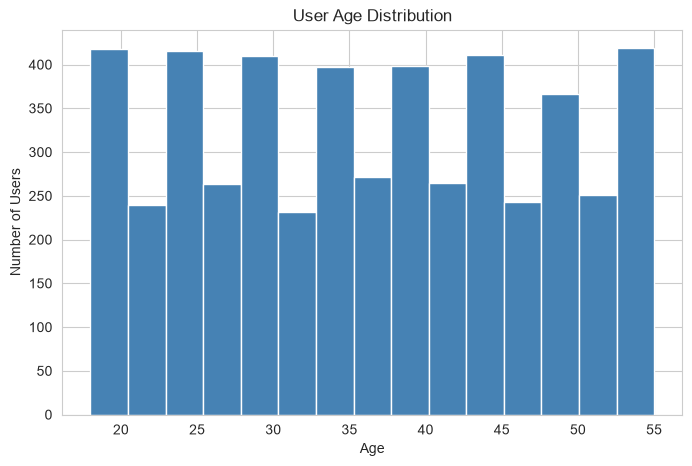

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(users["age"], bins=15, color="steelblue", edgecolor="white")
plt.title("User Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

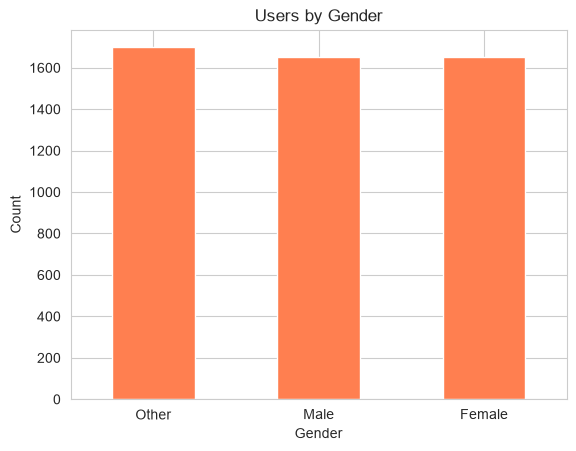

In [13]:
users["gender"].value_counts().plot.bar(color="coral")
plt.title("Users by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

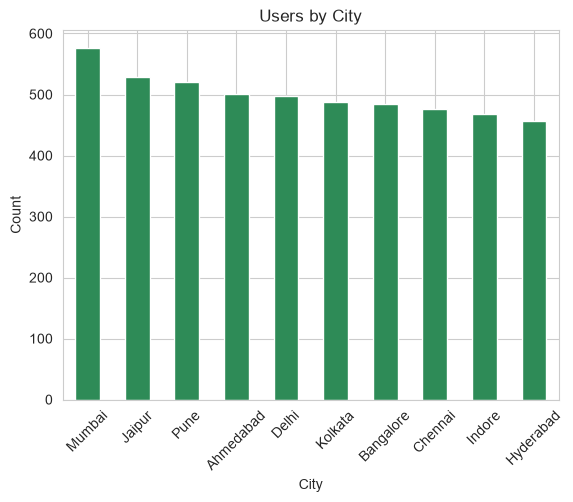

In [14]:
users["city"].value_counts().plot.bar(color="seagreen")
plt.title("Users by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

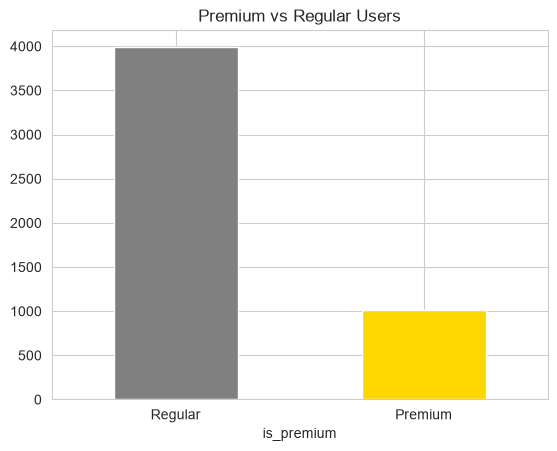

In [15]:
users["is_premium"].value_counts().rename({0: "Regular", 1: "Premium"}).plot.bar(color=["gray", "gold"])
plt.title("Premium vs Regular Users")
plt.xticks(rotation=0)
plt.show()

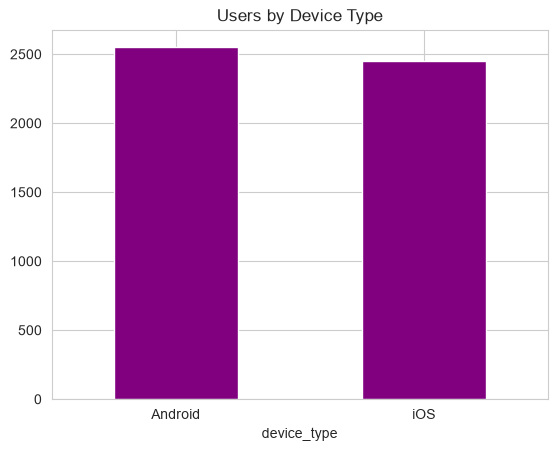

In [16]:
users["device_type"].value_counts().plot.bar(color="purple")
plt.title("Users by Device Type")
plt.xticks(rotation=0)
plt.show()

### Step 3B: Key Charts

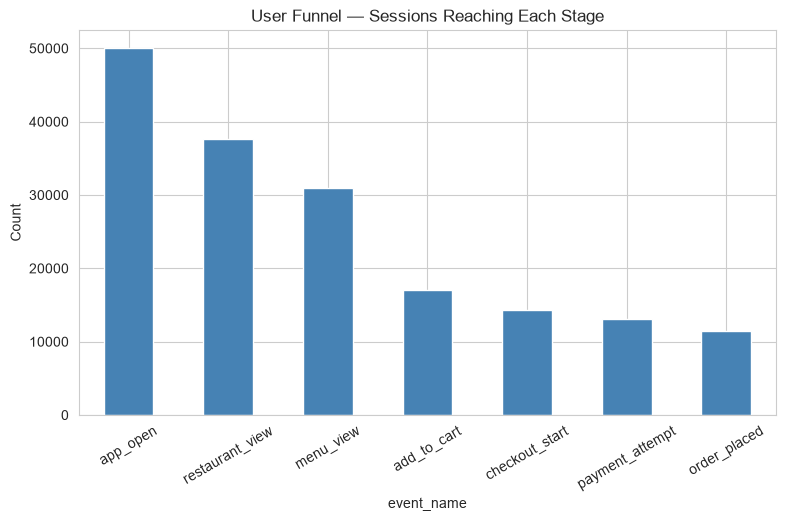

In [17]:
funnel_counts = events["event_name"].value_counts()
funnel_order = ["app_open", "restaurant_view", "menu_view", "add_to_cart",
                 "checkout_start", "payment_attempt", "order_placed"]
funnel_counts = funnel_counts.reindex(funnel_order)

funnel_counts.plot.bar(color="steelblue", figsize=(9, 5))
plt.title("User Funnel — Sessions Reaching Each Stage")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

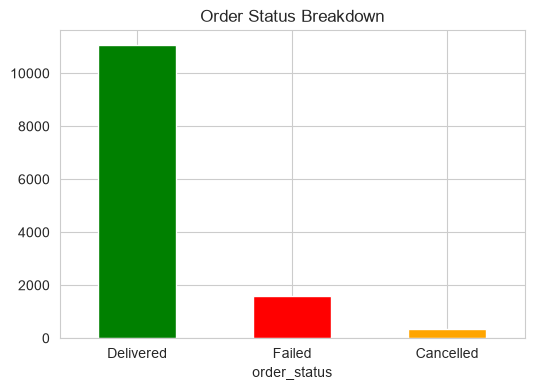

In [18]:
orders["order_status"].value_counts().plot.bar(color=["green", "red", "orange"], figsize=(6, 4))
plt.title("Order Status Breakdown")
plt.xticks(rotation=0)
plt.show()

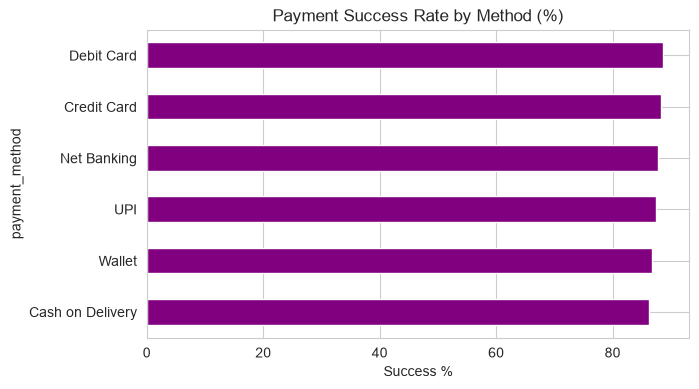

In [19]:
payment_success = orders.groupby("payment_method")["payment_status"].apply(
    lambda x: (x == "Success").mean() * 100
).sort_values()

payment_success.plot.barh(color="purple", figsize=(7, 4))
plt.title("Payment Success Rate by Method (%)")
plt.xlabel("Success %")
plt.show()

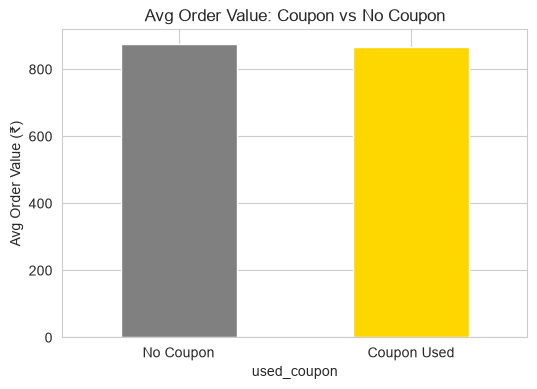

In [20]:
orders["used_coupon"] = orders["coupon_discount"] > 0

orders.groupby("used_coupon")["order_value"].mean().rename({False: "No Coupon", True: "Coupon Used"}).plot.bar(
    color=["gray", "gold"], figsize=(6, 4)
)
plt.title("Avg Order Value: Coupon vs No Coupon")
plt.ylabel("Avg Order Value (₹)")
plt.xticks(rotation=0)
plt.show()

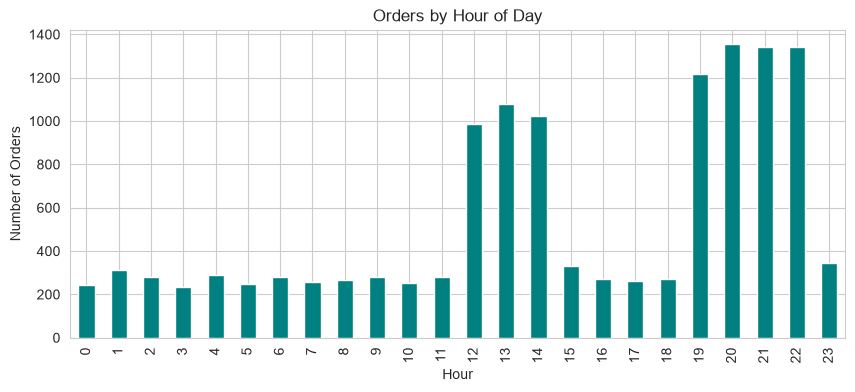

In [21]:
orders["order_hour"] = pd.to_datetime(orders["order_time"]).dt.hour

orders["order_hour"].value_counts().sort_index().plot.bar(color="teal", figsize=(10, 4))
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.show()

## Step 4: Restaurants EDA

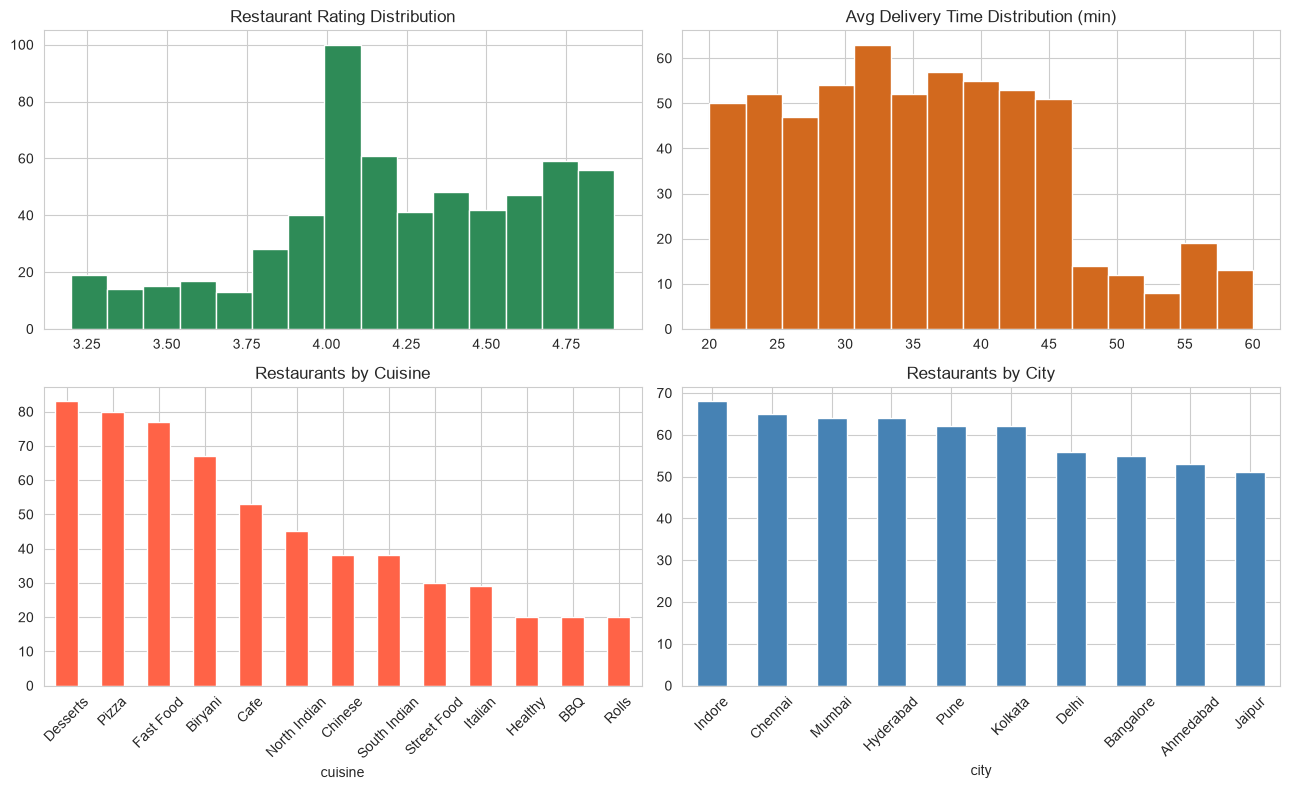

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(restaurants["rating"], bins=15, color="seagreen", edgecolor="white")
axes[0, 0].set_title("Restaurant Rating Distribution")

axes[0, 1].hist(restaurants["avg_delivery_time"], bins=15, color="chocolate", edgecolor="white")
axes[0, 1].set_title("Avg Delivery Time Distribution (min)")

restaurants["cuisine"].value_counts().plot.bar(ax=axes[1, 0], color="tomato")
axes[1, 0].set_title("Restaurants by Cuisine")
axes[1, 0].tick_params(axis="x", rotation=45)

restaurants["city"].value_counts().plot.bar(ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Restaurants by City")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Step 5: Menu Items EDA

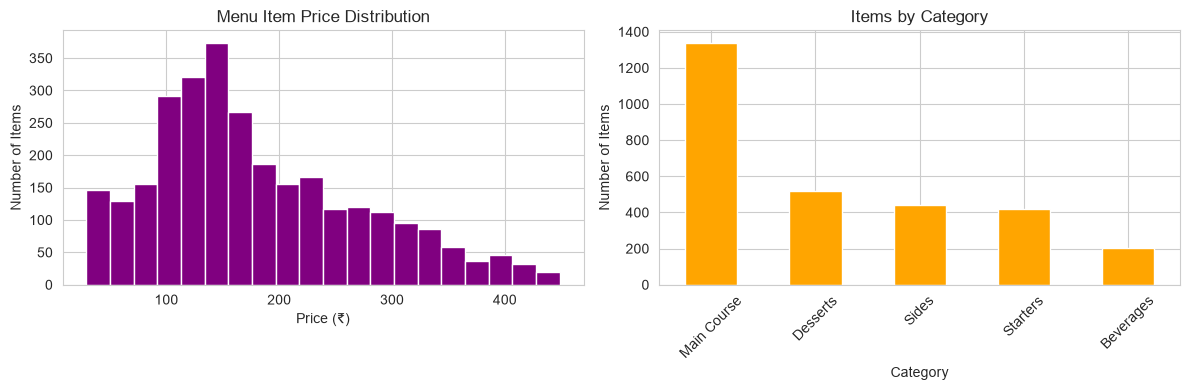

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(menu_items["price"], bins=20, color="purple", edgecolor="white")
axes[0].set_title("Menu Item Price Distribution")
axes[0].set_xlabel("Price (₹)")
axes[0].set_ylabel("Number of Items")

menu_items["category"].value_counts().plot.bar(ax=axes[1], color="orange")
axes[1].set_title("Items by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Number of Items")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Step 6: Sessions EDA

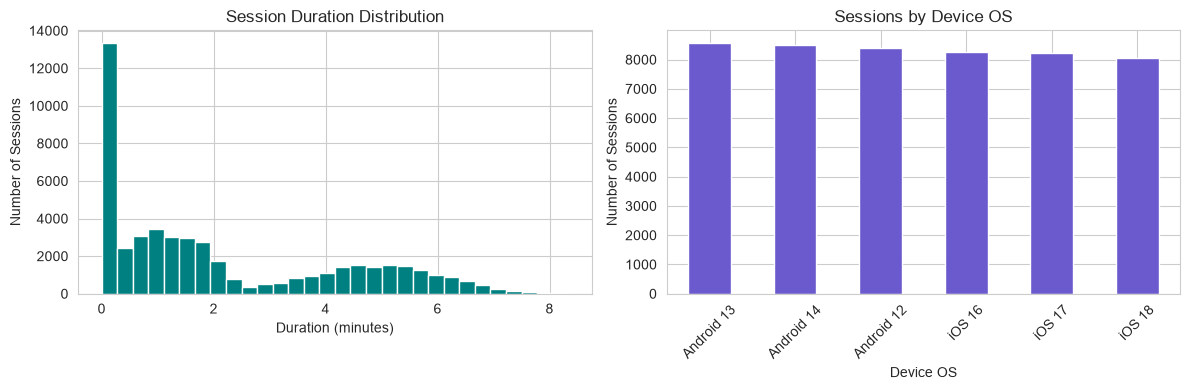

In [24]:
sessions["duration_min"] = (
    pd.to_datetime(sessions["session_end"]) - pd.to_datetime(sessions["session_start"])
).dt.total_seconds() / 60

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sessions["duration_min"], bins=30, color="teal", edgecolor="white")
axes[0].set_title("Session Duration Distribution")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Number of Sessions")

sessions["device_os"].value_counts().plot.bar(ax=axes[1], color="slateblue")
axes[1].set_title("Sessions by Device OS")
axes[1].set_xlabel("Device OS")
axes[1].set_ylabel("Number of Sessions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Step 7: Order Items EDA

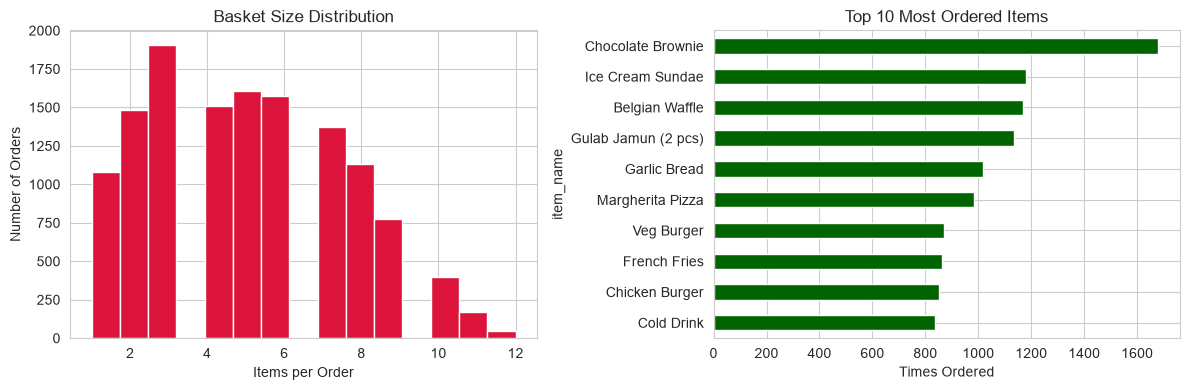

In [25]:
basket_size = order_items.groupby("order_id")["quantity"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(basket_size, bins=15, color="crimson", edgecolor="white")
axes[0].set_title("Basket Size Distribution")
axes[0].set_xlabel("Items per Order")
axes[0].set_ylabel("Number of Orders")

top_items = order_items.merge(menu_items[["item_id", "item_name"]], on="item_id")
top_items["item_name"].value_counts().head(10).plot.barh(ax=axes[1], color="darkgreen")
axes[1].set_title("Top 10 Most Ordered Items")
axes[1].set_xlabel("Times Ordered")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Key Insights from EDA

**Funnel drop-off (from `events`, 50,000 sessions):**
- App Open: 50,000 → Restaurant View: ~37,500 (75%) → Menu View: ~30,900 (82% of prev)
  → Add to Cart: ~17,000 (55% of prev) → Checkout Start: ~14,200 → Payment Attempt: 13,041
- The **biggest single drop is Menu View → Add to Cart (~45% of users leave without adding
  an item)** — this is the stage worth digging into first in the SQL analysis.
- ⚠️ **Data gap found:** the funnel chart shows 0 `order_placed` events, even though 11,074
  orders were actually delivered. `generate_orders.py` writes directly to `orders`/`order_items`
  but never logs an `order_placed` row back into `events`. Worth noting as a known limitation
  (or fixing later) — SQL funnel/conversion queries should use the `orders` table for the final
  stage, not `events`.

**Orders (13,041 total):**
- 84.9% Delivered (11,074), ~12% Failed, ~2.3% Cancelled after payment.
- Avg order value: ₹870, range ₹29–₹3,932.
- Avg delivery time (delivered orders only): 42 minutes.
- **Data integrity check:** `payment_attempt` events (13,041) exactly match the number of rows
  in `orders` — confirms every payment attempt produced exactly one order record, no orphans.

**Payments:**
- Success rate is ~86–88% and nearly identical across all 6 payment methods (Debit Card,
  Credit Card, Net Banking, UPI, Wallet, COD). No method stands out as meaningfully worse —
  expected, since the generator applies one flat success probability regardless of method.
  A more realistic dataset would vary failure rates by method (e.g., COD/Wallet more failure-prone).

**Coupons:**
- ~9,740 sessions (19.5% of all sessions, ~57% of cart-reaching sessions) applied a coupon —
  matches the generator's design (4 of 7 coupon options were non-null).
- Avg order value is nearly identical with vs without a coupon (₹870 vs ₹860) — because coupon
  assignment in the simulator is random, not tied to cart size. Real coupon-lift analysis will
  need to look at **conversion rate**, not order value, to be meaningful.

**Timing:**
- Orders show clear lunch (12–2 PM) and dinner (7–10 PM) peaks — confirms the traffic-shaping
  logic in the generator worked as intended.

**Restaurants:**
- Ratings cluster around 4.0–4.1 (driven by the fixed-brand restaurants), full range 3.2–4.9.
- Desserts, Pizza, and Fast Food are the most common cuisines; Healthy, BBQ, and Rolls the least.
- Restaurant count is fairly even across all 10 cities (51–68 each).

**Menu & Baskets:**
- Menu prices cluster ₹100–200; Main Course items dominate the menu (~1,340 of 2,920 items).
- Basket size peaks at 3 items per order.
- Top ordered items are dominated by desserts (Chocolate Brownie, Ice Cream Sundae, Belgian
  Waffle) — likely because Desserts appears in multiple cuisine menus, not just dessert-focused
  restaurants.

**Sessions:**
- Most sessions are very short (under 1 minute) — consistent with the high bounce rate seen in
  the funnel (most sessions end right after `app_open`).
- Device OS is evenly split across Android and iOS versions (~8,000–8,500 each).

These findings set up the next phase: targeted SQL queries on funnel conversion, coupon
effectiveness, payment failure reasons, and delivery impact on ratings.

**Funnel drop-off (from `events`, 50,000 sessions, after backfilling missing
`order_placed` events):**
- App Open: 50,000 → Restaurant View: 37,571 (75.1%) → Menu View: 30,920 (82.3% of prev)
  → Add to Cart: 17,064 (55.2% of prev) → Checkout Start: 14,294 → Payment Attempt: 13,041
  → Order Placed: 11,435
- The **biggest single drop is Menu View → Add to Cart (~45% of users leave without adding
  an item)** — this is the stage worth digging into first in the SQL analysis.

## Summary Statistics

In [27]:
print("USERS - Age")
display(users[["age"]].describe())

print("\nRESTAURANTS - Rating, Cost, Delivery")
display(restaurants[["rating", "average_cost", "delivery_fee", "avg_delivery_time"]].describe())

print("\nMENU ITEMS - Price")
display(menu_items[["price"]].describe())

print("\nORDERS - Value, Fees, Delivery Time")
display(orders[["order_value", "delivery_fee", "coupon_discount", "delivery_time_minutes"]].describe())

print("\nORDER ITEMS - Quantity, Price")
display(order_items[["quantity", "price_at_purchase"]].describe())

USERS - Age


,age
count,5000.000000
mean,36.417800
std,10.996373
min,18.000000
25%,27.000000
50%,36.000000
75%,46.000000
max,55.000000



RESTAURANTS - Rating, Cost, Delivery


,rating,average_cost,delivery_fee,avg_delivery_time
count,600.000000,600.000000,600.000000,600.000000
mean,4.225500,518.105000,36.116667,35.508333
std,0.413866,189.819132,12.872291,9.594270
min,3.200000,155.000000,20.000000,20.000000
25%,4.000000,365.750000,20.000000,28.000000
50%,4.200000,503.000000,40.000000,35.000000
75%,4.600000,665.000000,50.000000,42.000000
max,4.900000,900.000000,60.000000,60.000000



MENU ITEMS - Price


,price
count,2920.000000
mean,180.339962
std,92.744909
min,29.100000
25%,113.330000
50%,158.035000
75%,238.097500
max,448.710000



ORDERS - Value, Fees, Delivery Time


,order_value,delivery_fee,coupon_discount,delivery_time_minutes
count,13041.000000,13041.000000,13041.000000,11074.000000
mean,870.203354,30.452419,56.505286,42.093372
std,595.025192,17.556069,75.612260,16.083144
min,29.100000,0.000000,0.000000,20.000000
25%,407.330000,20.000000,0.000000,30.000000
50%,757.230000,30.000000,50.000000,39.000000
75%,1190.510000,40.000000,100.000000,50.000000
max,3932.440000,60.000000,697.090000,105.000000



ORDER ITEMS - Quantity, Price


,quantity,price_at_purchase
count,32726.000000,32726.000000
mean,1.994591,174.022774
std,0.816522,89.743443
min,1.000000,29.100000
25%,1.000000,110.070000
50%,2.000000,153.550000
75%,3.000000,227.590000
max,3.000000,448.710000


## Correlation Analysis


In [28]:
# Join orders with users and restaurants to get a rich numeric dataset
corr_df = orders.merge(users[["user_id", "age", "is_premium"]], on="user_id")
corr_df = corr_df.merge(restaurants[["restaurant_id", "rating", "avg_delivery_time"]], on="restaurant_id")

numeric_cols = [
    "order_value", "delivery_fee", "coupon_discount", "delivery_time_minutes",
    "age", "is_premium", "rating", "avg_delivery_time"
]

corr_matrix = corr_df[numeric_cols].corr()
display(corr_matrix.round(2))

,order_value,delivery_fee,coupon_discount,delivery_time_minutes,age,is_premium,rating,avg_delivery_time
order_value,1.00,-0.02,0.22,-0.02,0.00,-0.01,0.04,-0.03
delivery_fee,-0.02,1.00,0.08,0.03,-0.02,0.00,-0.07,0.04
coupon_discount,0.22,0.08,1.00,-0.01,0.00,-0.01,0.02,-0.01
delivery_time_minutes,-0.02,0.03,-0.01,1.00,0.02,-0.00,-0.15,0.61
age,0.00,-0.02,0.00,0.02,1.00,-0.01,-0.01,0.01
is_premium,-0.01,0.00,-0.01,-0.00,-0.01,1.00,-0.01,-0.00
rating,0.04,-0.07,0.02,-0.15,-0.01,-0.01,1.00,-0.22
avg_delivery_time,-0.03,0.04,-0.01,0.61,0.01,-0.00,-0.22,1.00


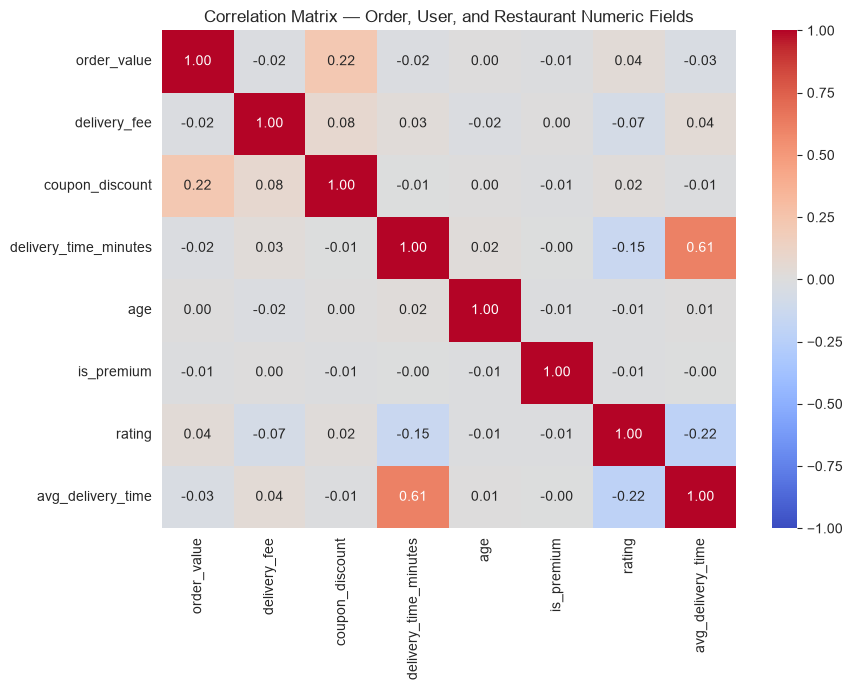

In [29]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Order, User, and Restaurant Numeric Fields")
plt.tight_layout()
plt.show()

## Value Counts — Key Categorical Columns

In [30]:
print("Payment Method distribution:")
display(orders["payment_method"].value_counts())

print("\nPayment Status distribution:")
display(orders["payment_status"].value_counts())

print("\nOrder Status distribution:")
display(orders["order_status"].value_counts())

print("\nCuisine distribution:")
display(restaurants["cuisine"].value_counts())

print("\nUser Gender distribution:")
display(users["gender"].value_counts())

print("\nUser City distribution:")
display(users["city"].value_counts())

Payment Method distribution:


payment_method
UPI                 5944
Credit Card         1949
Debit Card          1934
Wallet              1541
Net Banking         1072
Cash on Delivery     601
Name: count, dtype: int64


Payment Status distribution:


payment_status
Success    11435
Failed      1606
Name: count, dtype: int64


Order Status distribution:


...

cuisine
Desserts        83
Pizza           80
Fast Food       77
Biryani         67
Cafe            53
North Indian    45
Chinese         38
South Indian    38
Street Food     30
Italian         29
Healthy         20
BBQ             20
Rolls           20
Name: count, dtype: int64


User Gender distribution:


gender
Other     1699
Male      1651
Female    1650
Name: count, dtype: int64


User City distribution:


city
Mumbai       577
Jaipur       529
Pune         521
Ahmedabad    501
Delhi        498
Kolkata      488
Bangalore    485
Chennai      476
Indore       468
Hyderabad    457
Name: count, dtype: int64